## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">E-Commerce Sales Analysis & Profit Margin Prediction</p>

<a id="toc"></a>

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Content</p>

* [INTRODUCTION](#0)
* [IMPORTING MODULES, LOADING DATA & DATA REVIEW](#1)
* [PREPROCESSING](#2)
* [EXPLORATORY DATA ANALYSIS (EDA)](#3)    
* [SCALING, CATEGORICAL VARIABLES, SPLITTING](#4)
* [MODELS](#5)
* [CONCLUSION](#6)

## <p style="background-color:#fea162; font-family:'Times New Roman', Times, serif; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Introduction</p>

<a id="0"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true"
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 1.1 Information About the Project
This project analyzes and models an e-commerce sales transactions dataset containing 34,500 records and 17 features. The dataset simulates online shopping behavior and can be used for several machine learning related tasks.

**Objective:**  
The main objective of this project is to build a machine learning model to predict profit margin. Since the target variable (profit margin) is continuous, this is a regression task. Predicting profit can help businesses to improve pricing strategies, optimize discounts, and reduce overall losses.

**Scope:**  
This project includes exploratory data analysis, feature engineering, data preprocessing, model training and evaluation, and building a deployable machine learning model.

## 1.2 Description of the Dataset
The dataset, titled E-Commerce Sales Transactions Dataset, was obtained from Kaggle. 

- **Size:** 34,500 rows (records) and 17 columns (features)
- **Type:** Tabular dataset that contains numerical features, categorical features, and date-time data

## 1.3 Description of the Columns

- **Target Variable:** 
    - profit_margin (continuous numerical variable that represents the profit earned from each order)
- **Feature Variables:** 
    - order_id (categorial variable that represents a unique identifier for each order)
    - customer_id (categorical variable that represents a unique identifier for each customer)
    - product_id (categorical variable that represents a unique identifier for each product)
    - category (nominal categorical variable that represents the product category)
    - price (continuous numerical variable that represents the unit price of the product)
    - discount (continuous numerical variable that represents the discount applied (%))
    - quantity (discrete numerical variable that represents the number of items purchased)
    - customer_age (continuous numerical variable that represents the age of the customer)
    - customer_gender (nominal categorical variable that represents the gender of the customer)
    - payment_method (nominal categorical variable that represents the payment type)
    - region (nominal categorical variable that represents the geographic region of the customer)
    - order_date (datetime variable that represents the date when the order was placed)
    - delivery_time_days (numerical variable that represents the number of days taken for delivery)
    - total_amount (continuous numerical variable that represents the final amount paid after discounts)
    - shipping_cost (continuous numerical variable that represents the delivery charges)
    - returned (categorical variable that represents whether the product was returned or not)

---



## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Importing Modules, Load Data & Data Review</p>

<a id="1"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

In [1]:
import sys
!{sys.executable} -m pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/e-commerce-sales-transactions-dataset")

print("Path to dataset files:", path)

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/nikhila/.cache/kagglehub/datasets/miadul/e-commerce-sales-transactions-dataset/versions/1


In [2]:
dataset_path = "/Users/nikhila/.cache/kagglehub/datasets/miadul/e-commerce-sales-transactions-dataset/versions/1"
import os
os.listdir(dataset_path)

['ecommerce_sales_34500.csv']

In [3]:
import os
%pip install pandas
import pandas as pd

dataset_path = "/Users/nikhila/.cache/kagglehub/datasets/miadul/e-commerce-sales-transactions-dataset/versions/1"

# Get the csv file automatically
files = os.listdir(dataset_path)
csv_file = [f for f in files if f.endswith(".csv")][0]

file_path = os.path.join(dataset_path, csv_file)

df = pd.read_csv(file_path)

df.head()

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [4]:
print(df.shape)        # rows, columns
print(df.columns)    # column names
print(df.info())       # data types & missing values

(34500, 17)
Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  i

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Preprocessing</p>

<a id="2"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 2.1 Data Cleaning
Cleaning the dataset is critical before any analysis.

- **Duplicates:** Remove duplicate records.
- **Inconsistent Formats:** Address inconsistent data formats (e.g., date formats, string casing).
- **Incorrect Data:** Handle obvious data errors. 

In [5]:
df = df.drop_duplicates()

In [6]:
df['order_id'].value_counts()

order_id
O100000    1
O122995    1
O123009    1
O123008    1
O123007    1
          ..
O111494    1
O111493    1
O111492    1
O111491    1
O134499    1
Name: count, Length: 34500, dtype: int64

In [7]:
#Checking for any inconsistent data format in order_id column
df['order_id'].str.match(r'O\d{6}$').value_counts()


order_id
True    34500
Name: count, dtype: int64

In [8]:
df['customer_id'].value_counts()

customer_id
C11573    13
C16704    13
C17824    12
C14228    12
C12415    12
          ..
C13946     1
C11684     1
C12622     1
C12884     1
C14730     1
Name: count, Length: 7903, dtype: int64

In [9]:
#Checking for any inconsistent data format in customer_id column
df['customer_id'].str.match(r'C\d{5}$').value_counts()

customer_id
True    34500
Name: count, dtype: int64

In [10]:
df['product_id'].value_counts()

product_id
P200645    7
P218083    6
P237997    6
P224107    6
P235301    6
          ..
P221302    1
P212276    1
P201350    1
P245756    1
P207047    1
Name: count, Length: 24912, dtype: int64

In [11]:
#Checking for any inconsistent data format in product_id column
df['product_id'].str.match(r'P\d{6}$').value_counts()

product_id
True    34500
Name: count, dtype: int64

In [12]:
df['category'].value_counts()

category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

In [13]:
df['price'].value_counts()

price
13.58      17
3.71       15
5.11       15
2.22       14
5.26       14
           ..
1466.62     1
57.99       1
122.09      1
425.78      1
323.64      1
Name: count, Length: 17274, dtype: int64

In [14]:
df['discount'].value_counts()

discount
0.00    18939
0.05     6176
0.10     4159
0.15     2795
0.20     1727
0.30      704
Name: count, dtype: int64

In [15]:
df['quantity'].value_counts()

quantity
1    24837
2     5138
3     2455
4     1398
5      672
Name: count, dtype: int64

In [16]:
df['payment_method'].value_counts()

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

In [17]:
#Converting the order_date column into a datetime variable
df['order_date'] = pd.to_datetime(df['order_date'])

In [18]:
df['delivery_time_days'].value_counts()

delivery_time_days
5     10296
4     10094
6      5961
3      4907
7      2400
8       663
9       152
10       25
13        1
12        1
Name: count, dtype: int64

In [19]:
df['region'].value_counts()

region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

In [20]:
df['returned'].value_counts()

returned
No     32597
Yes     1903
Name: count, dtype: int64

In [21]:
df['total_amount'].value_counts()

total_amount
6.03       14
3.52       14
6.80       14
10.74      13
13.30      13
           ..
544.05      1
339.06      1
760.81      1
102.83      1
1618.20     1
Name: count, Length: 18800, dtype: int64

In [22]:
df['shipping_cost'].value_counts()

shipping_cost
6.95     74
5.95     68
6.17     67
7.20     67
5.65     67
         ..
12.78     1
12.36     1
0.48      1
0.39      1
13.24     1
Name: count, Length: 1304, dtype: int64

In [23]:
df['profit_margin'].value_counts()

profit_margin
-0.55      28
 0.10      28
 0.15      27
 0.93      27
-0.43      27
           ..
 123.04     1
 79.91      1
 38.08      1
 36.38      1
 182.00     1
Name: count, Length: 9603, dtype: int64

In [24]:
df['customer_age'].value_counts()

customer_age
25    743
43    709
53    706
62    699
33    696
69    694
41    689
48    687
38    686
45    685
34    682
54    681
29    680
59    676
19    675
46    673
47    672
20    672
68    671
30    669
60    668
40    668
35    666
31    666
63    666
24    663
28    662
37    659
36    658
26    658
61    657
44    657
58    656
50    655
23    653
57    651
66    650
27    650
32    649
18    647
52    646
21    644
42    642
51    642
56    641
64    641
65    640
55    640
67    627
39    625
49    607
22    601
Name: count, dtype: int64

In [25]:
df['customer_gender'].value_counts()

customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64

## 2.2 Missing Value Analysis

In [26]:
#Dataset contains no missing values
df.isna().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

## 2.3 Outlier Analysis
Identifying and handling outliers in the data. Plotting features using boxplots to visualize outliers.

In [27]:
df['price'].describe()

count    34500.000000
mean       119.391632
std        195.620477
min          1.010000
25%         16.690000
50%         45.660000
75%        130.950000
max       2930.470000
Name: price, dtype: float64

In [28]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
ul = Q3 + 1.5 * IQR
ll = Q1 - 1.5 * IQR
df[(df['price'] > ul) | (df['price'] < ll)]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
18,O100018,C17831,P218405,Electronics,734.32,0.00,2,Wallet,2025-06-20,4,South,No,1468.64,10.90,165.34,58,Female
24,O100024,C15611,P247930,Sports,345.57,0.15,2,Debit Card,2024-04-16,5,Central,No,587.47,9.48,166.76,32,Female
44,O100044,C17643,P243790,Electronics,313.25,0.00,1,Debit Card,2024-09-27,8,Central,No,313.25,8.96,28.63,53,Male
53,O100053,C11899,P229316,Electronics,402.13,0.00,2,PayPal,2024-01-24,5,South,No,804.26,9.93,86.58,40,Female
62,O100062,C16164,P223089,Electronics,368.67,0.00,1,Debit Card,2024-06-26,6,West,No,368.67,9.91,34.33,36,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34441,O134441,C17508,P222415,Electronics,827.41,0.00,1,Wallet,2024-03-09,4,West,No,827.41,10.44,88.85,29,Female
34445,O134445,C11663,P212348,Electronics,519.86,0.05,1,PayPal,2025-03-27,3,Central,No,493.87,10.06,49.20,51,Male
34464,O134464,C17157,P245828,Electronics,372.13,0.00,1,Credit Card,2024-03-10,3,North,Yes,372.13,10.75,33.91,33,Female
34473,O134473,C17379,P217724,Electronics,817.80,0.00,1,Debit Card,2024-02-06,5,East,No,817.80,9.06,89.08,32,Female


You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


Text(0.5, 1.0, 'Boxplot of Price')

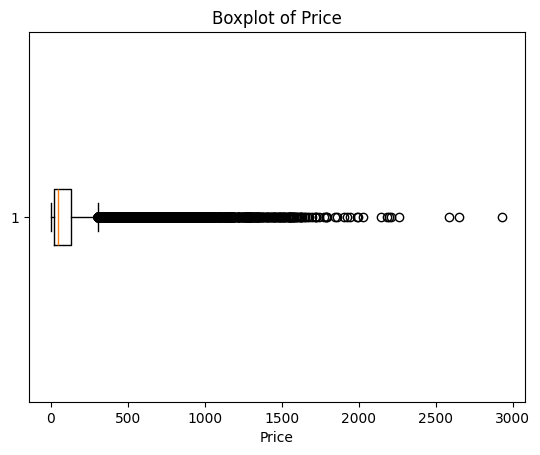

In [29]:
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt
plt.boxplot(df['price'], vert = False)
plt.xlabel('Price')
plt.title('Boxplot of Price')

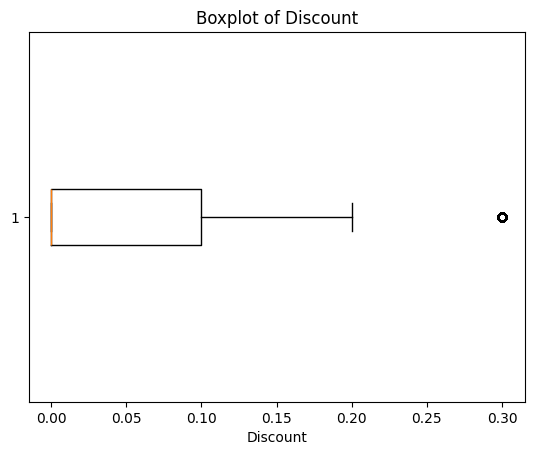

In [30]:
plt.boxplot(df['discount'], vert = False)
plt.xlabel('Discount')
plt.title('Boxplot of Discount')
plt.show()

Text(0.5, 1.0, 'Boxplot of Quantity')

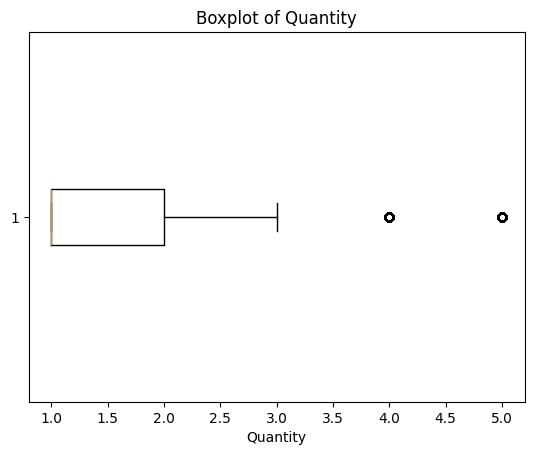

In [31]:
plt.boxplot(df['quantity'], vert = False)
plt.xlabel('Quantity')
plt.title('Boxplot of Quantity')

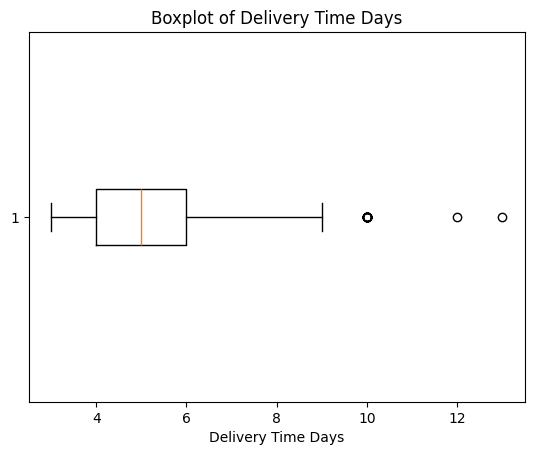

In [32]:
plt.boxplot(df['delivery_time_days'], vert = False)
plt.xlabel('Delivery Time Days')
plt.title('Boxplot of Delivery Time Days')
plt.show()

In [33]:
df['total_amount'].describe()

count    34500.000000
mean       170.008494
std        357.503014
min          0.820000
25%         19.710000
50%         56.820000
75%        168.530000
max      12931.800000
Name: total_amount, dtype: float64

In [34]:
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
IQR = Q3 - Q1
ll = Q1 - 1.5 * IQR
ul = Q3 + 1.5 * IQR
df[(df['total_amount'] < ll) | (df['total_amount'] > ul)]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
18,O100018,C17831,P218405,Electronics,734.32,0.00,2,Wallet,2025-06-20,4,South,No,1468.64,10.90,165.34,58,Female
24,O100024,C15611,P247930,Sports,345.57,0.15,2,Debit Card,2024-04-16,5,Central,No,587.47,9.48,166.76,32,Female
51,O100051,C13005,P243043,Home,195.87,0.00,4,Credit Card,2024-12-31,5,West,No,783.48,10.37,209.00,43,Female
53,O100053,C11899,P229316,Electronics,402.13,0.00,2,PayPal,2024-01-24,5,South,No,804.26,9.93,86.58,40,Female
57,O100057,C11528,P246809,Home,167.21,0.00,4,Wallet,2023-12-06,3,North,No,668.84,8.88,178.40,37,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34445,O134445,C11663,P212348,Electronics,519.86,0.05,1,PayPal,2025-03-27,3,Central,No,493.87,10.06,49.20,51,Male
34467,O134467,C14416,P227891,Fashion,78.95,0.00,5,Debit Card,2024-01-17,6,South,Yes,394.75,7.55,130.61,23,Male
34473,O134473,C17379,P217724,Electronics,817.80,0.00,1,Debit Card,2024-02-06,5,East,No,817.80,9.06,89.08,32,Female
34493,O134493,C14637,P230371,Sports,109.45,0.00,4,Debit Card,2024-08-17,5,West,No,437.80,9.52,121.82,65,Male


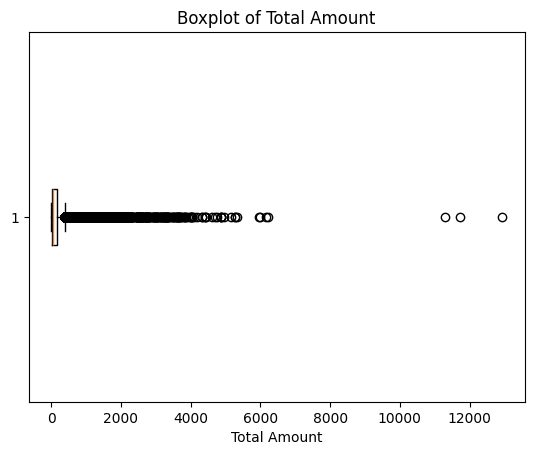

In [35]:
plt.boxplot(df['total_amount'], vert = False)
plt.xlabel('Total Amount')
plt.title('Boxplot of Total Amount')
plt.show()

In [36]:
df['shipping_cost'].describe()

count    34500.000000
mean         6.152120
std          2.389539
min          0.000000
25%          4.420000
50%          6.090000
75%          7.830000
max         15.650000
Name: shipping_cost, dtype: float64

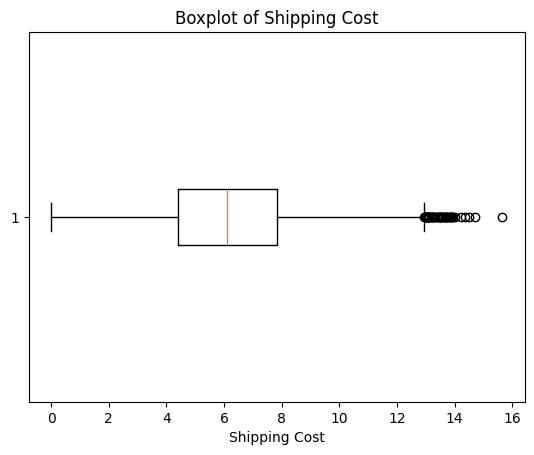

In [37]:
plt.boxplot(df['shipping_cost'], vert = False)
plt.xlabel('Shipping Cost')
plt.title('Boxplot of Shipping Cost')
plt.show()

In [38]:
df['profit_margin'].describe()

count    34500.000000
mean        28.116505
std         53.352947
min         -6.200000
25%          1.500000
50%         10.550000
75%         33.132500
max       1536.170000
Name: profit_margin, dtype: float64

In [39]:
Q1 = df['profit_margin'].quantile(0.25)
Q3 = df['profit_margin'].quantile(0.75)
IQR = Q3 - Q1
ul = Q3 + 1.5 * IQR
ll = Q1 - 1.5 * IQR
df[(df['profit_margin'] > ul) | (df['profit_margin'] < ll)]

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
18,O100018,C17831,P218405,Electronics,734.32,0.00,2,Wallet,2025-06-20,4,South,No,1468.64,10.90,165.34,58,Female
24,O100024,C15611,P247930,Sports,345.57,0.15,2,Debit Card,2024-04-16,5,Central,No,587.47,9.48,166.76,32,Female
51,O100051,C13005,P243043,Home,195.87,0.00,4,Credit Card,2024-12-31,5,West,No,783.48,10.37,209.00,43,Female
53,O100053,C11899,P229316,Electronics,402.13,0.00,2,PayPal,2024-01-24,5,South,No,804.26,9.93,86.58,40,Female
57,O100057,C11528,P246809,Home,167.21,0.00,4,Wallet,2023-12-06,3,North,No,668.84,8.88,178.40,37,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34460,O134460,C10265,P232438,Sports,226.26,0.15,2,PayPal,2024-02-13,4,North,No,384.64,8.66,106.73,56,Female
34467,O134467,C14416,P227891,Fashion,78.95,0.00,5,Debit Card,2024-01-17,6,South,Yes,394.75,7.55,130.61,23,Male
34473,O134473,C17379,P217724,Electronics,817.80,0.00,1,Debit Card,2024-02-06,5,East,No,817.80,9.06,89.08,32,Female
34493,O134493,C14637,P230371,Sports,109.45,0.00,4,Debit Card,2024-08-17,5,West,No,437.80,9.52,121.82,65,Male


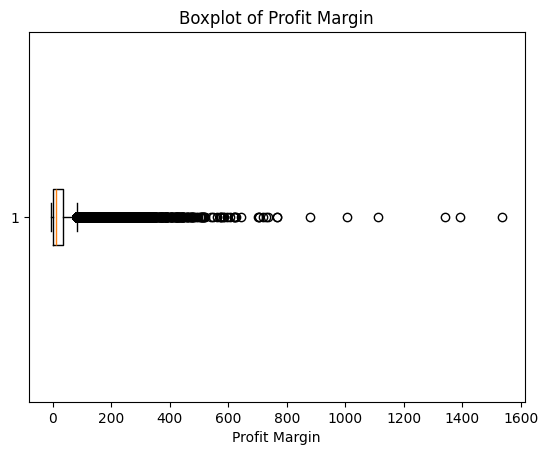

In [40]:
plt.boxplot(df['profit_margin'], vert = False)
plt.xlabel('Profit Margin')
plt.title('Boxplot of Profit Margin')
plt.show()

In [41]:
df['customer_age'].describe()

count    34500.000000
mean        43.474377
std         14.980682
min         18.000000
25%         31.000000
50%         43.000000
75%         56.000000
max         69.000000
Name: customer_age, dtype: float64

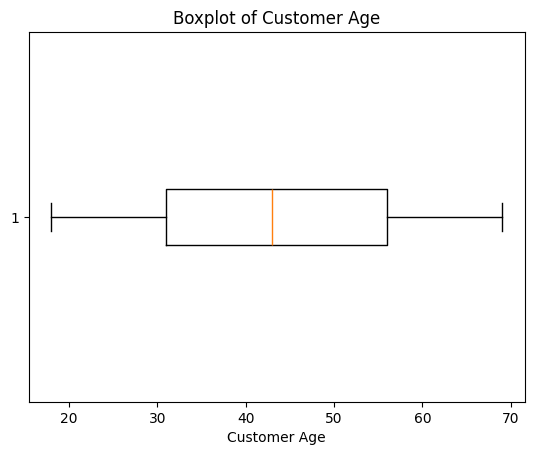

In [42]:
plt.boxplot(df['customer_age'], vert = False)
plt.xlabel('Customer Age')
plt.title('Boxplot of Customer Age')
plt.show()

## 2.4 Feature Engineering
Creating new features to improve model performance.

In [43]:
#Creating features to identify if sales differ throughout the year
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.dayofweek
df['quarter'] = df['order_date'].dt.quarter


## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Exploratory Data Analysis (EDA)</p>

<a id="3"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 3.1 Data Visualization
Visualizing the data to identify trends, patterns, or anomalies.

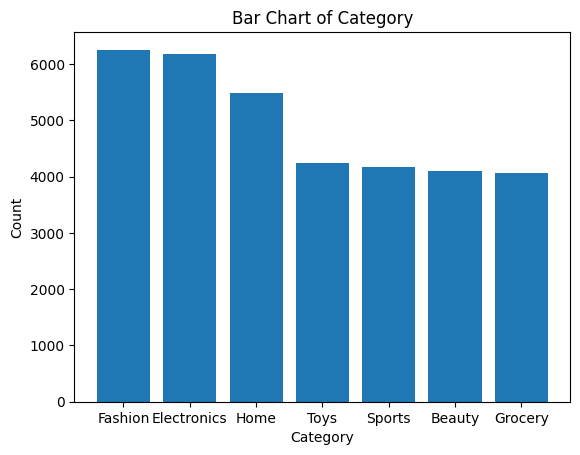

In [44]:
counts = df['category'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Bar Chart of Category')
plt.show()

Text(0.5, 1.0, 'Histogram of Price')

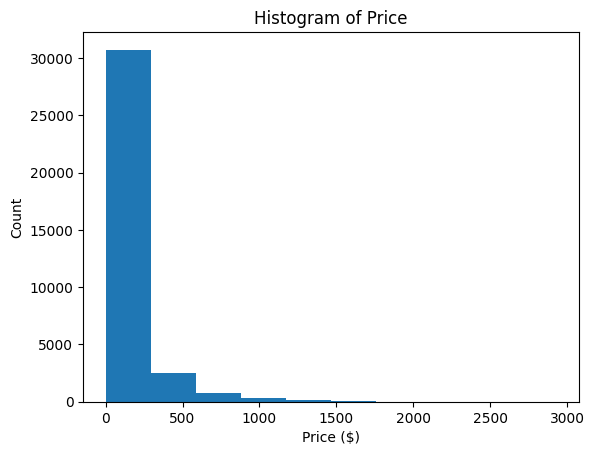

In [45]:
plt.hist(df['price'])
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.title('Histogram of Price')

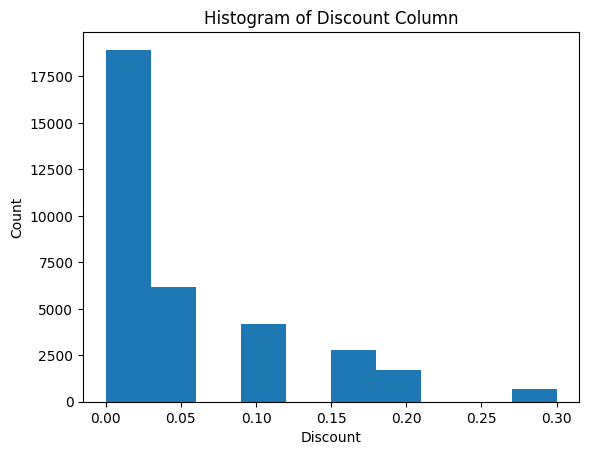

In [46]:
plt.hist(df['discount'])
plt.xlabel('Discount')
plt.ylabel('Count')
plt.title('Histogram of Discount Column')
plt.show()

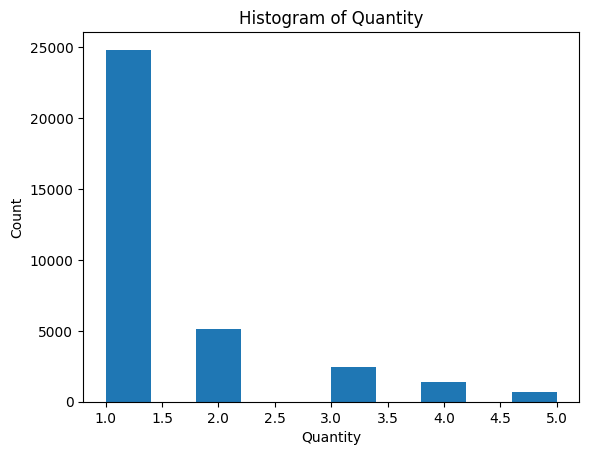

In [47]:
plt.hist(df['quantity'])
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.title('Histogram of Quantity')
plt.show()

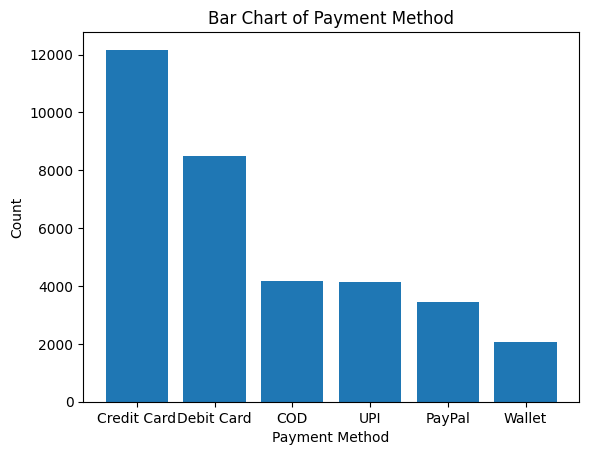

In [48]:
counts = df['payment_method'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.title("Bar Chart of Payment Method")
plt.show()

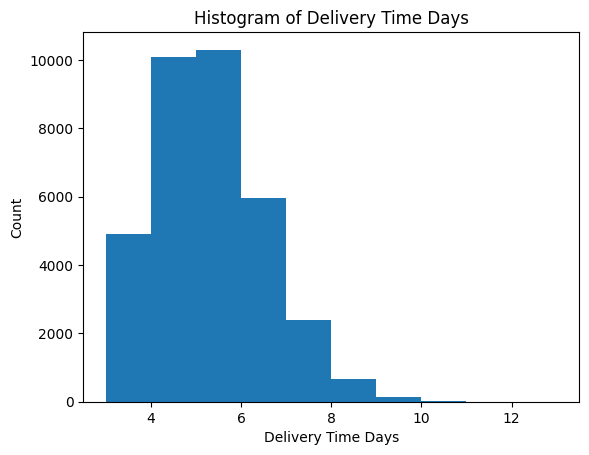

In [49]:
plt.hist(df['delivery_time_days'])
plt.xlabel('Delivery Time Days')
plt.ylabel('Count')
plt.title('Histogram of Delivery Time Days')
plt.show()

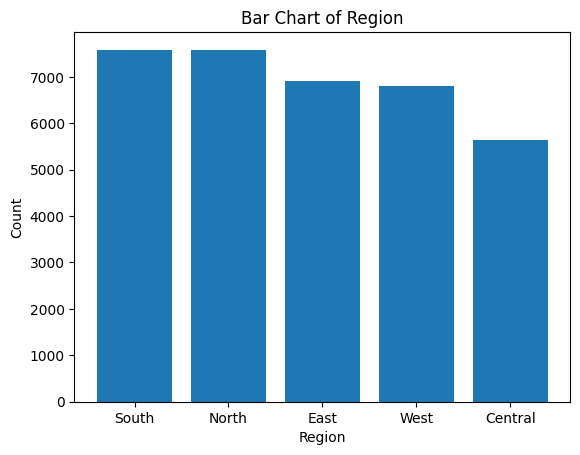

In [50]:
counts = df['region'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('Region')
plt.ylabel('Count')
plt.title('Bar Chart of Region')
plt.show()

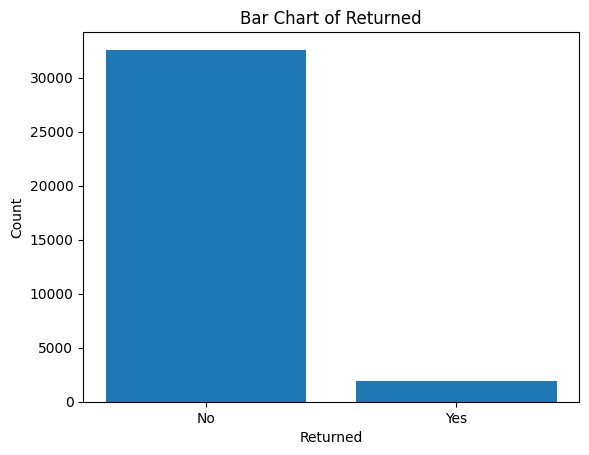

In [51]:
counts = df['returned'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('Returned')
plt.ylabel('Count')
plt.title('Bar Chart of Returned')
plt.show()

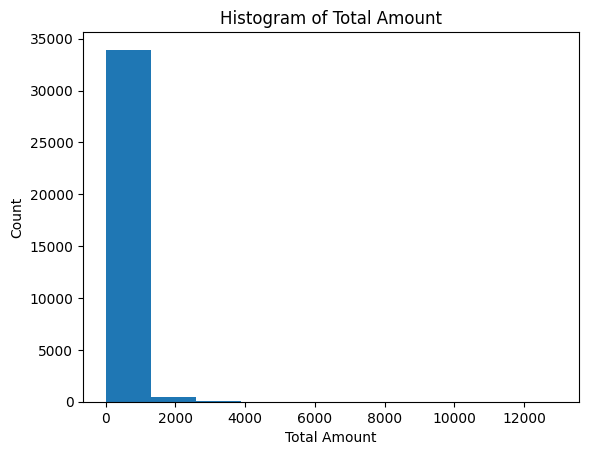

In [52]:
plt.hist(df['total_amount'])
plt.xlabel('Total Amount')
plt.ylabel('Count')
plt.title('Histogram of Total Amount')
plt.show()

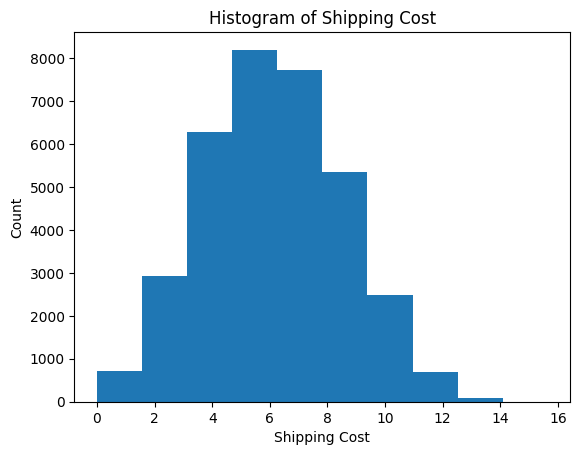

In [53]:
plt.hist(df['shipping_cost'])
plt.xlabel('Shipping Cost')
plt.ylabel('Count')
plt.title('Histogram of Shipping Cost')
plt.show()

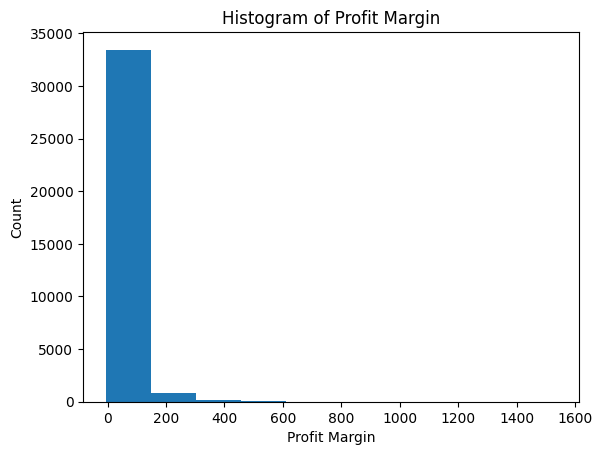

In [54]:
plt.hist(df['profit_margin'])
plt.xlabel('Profit Margin')
plt.ylabel('Count')
plt.title('Histogram of Profit Margin')
plt.show()

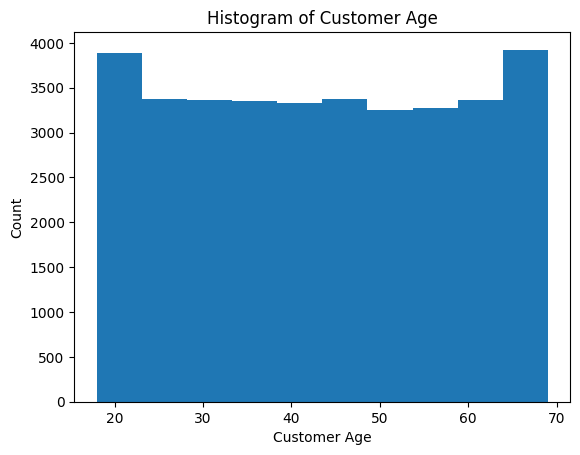

In [55]:
plt.hist(df['customer_age'])
plt.xlabel('Customer Age')
plt.ylabel('Count')
plt.title('Histogram of Customer Age')
plt.show()

Text(0.5, 1.0, 'Bar Chart of Customer Gender')

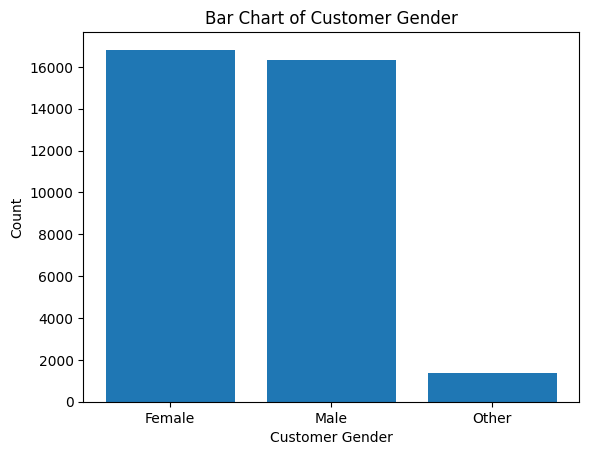

In [56]:
count = df['customer_gender'].value_counts()
plt.bar(count.index, count.values)
plt.xlabel('Customer Gender')
plt.ylabel('Count')
plt.title('Bar Chart of Customer Gender')

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


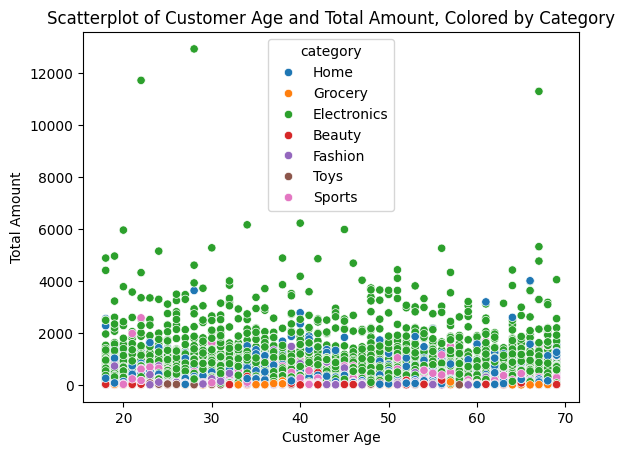

In [57]:
!{sys.executable} -m pip install seaborn
import seaborn as sns

sns.scatterplot(data=df, x='customer_age', y='total_amount', hue='category')
plt.xlabel('Customer Age')
plt.ylabel('Total Amount')
plt.title('Scatterplot of Customer Age and Total Amount, Colored by Category')
plt.show()

#Most purchases are in the electronics category, and the highest amount of money was purchased by people in their mid 20s and 30s.

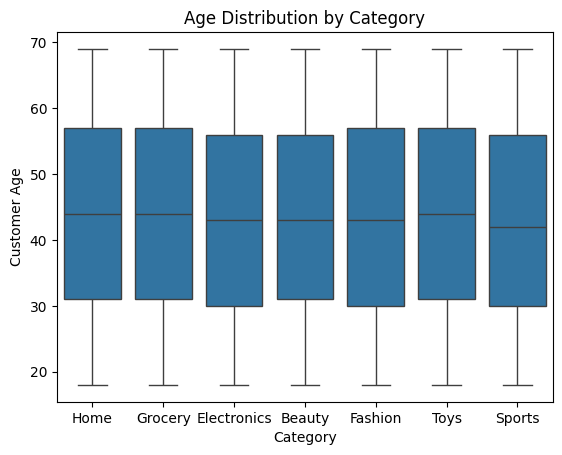

In [58]:
sns.boxplot(data = df, x = "category", y = "customer_age")
plt.xlabel('Category')
plt.ylabel('Customer Age')
plt.title("Age Distribution by Category")
plt.show()

Text(0.5, 1.0, 'Total Amount Distribution by Gender')

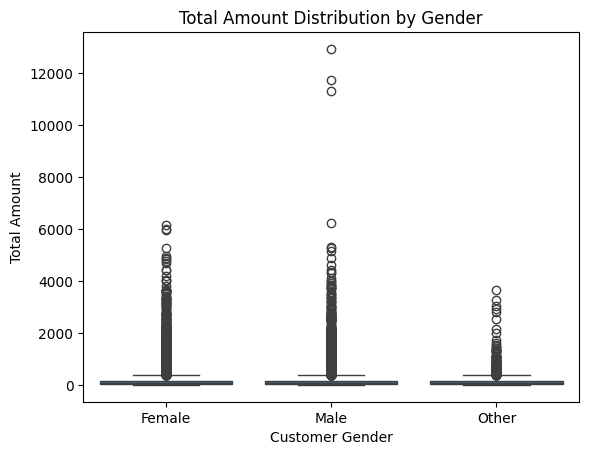

In [59]:
sns.boxplot(data = df, x = df['customer_gender'], y = df['total_amount'])
plt.xlabel('Customer Gender')
plt.ylabel('Total Amount')
plt.title('Total Amount Distribution by Gender')

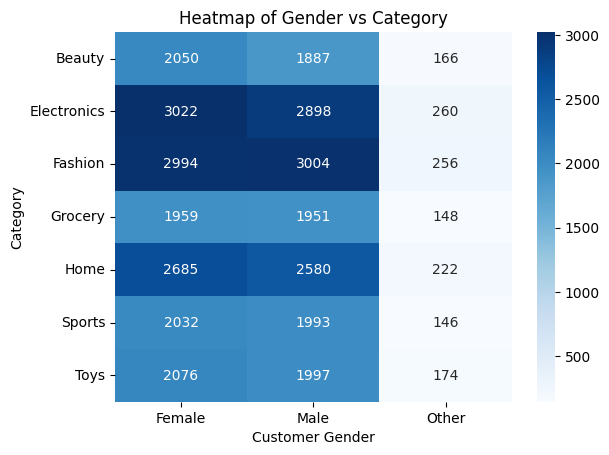

In [60]:
sns.heatmap(pd.crosstab(df['category'], df['customer_gender']), annot=True, fmt="d", cmap="Blues")
plt.xlabel('Customer Gender')
plt.ylabel('Category')
plt.title("Heatmap of Gender vs Category")
plt.show()

#Most of the females and males make purchases related to Electronics and Fashion.

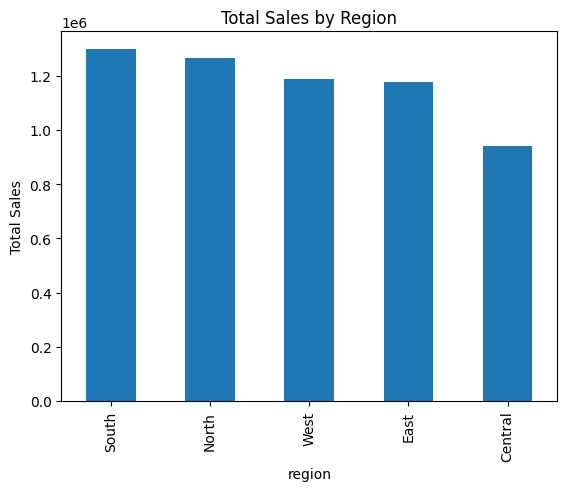

In [61]:
region_sales = df.groupby("region")["total_amount"].sum().sort_values(ascending=False)
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.ylabel("Total Sales")
plt.show()
#Most of the purchases come from the South region; the central region has the least amount of purchases.

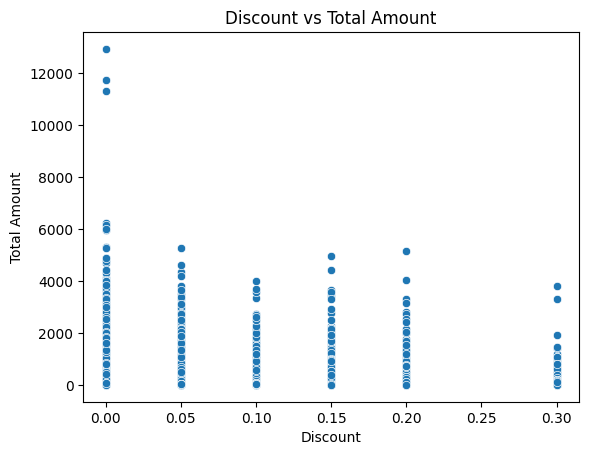

In [62]:
sns.scatterplot(data=df, x="discount", y="total_amount")
plt.title("Discount vs Total Amount")
plt.xlabel('Discount')
plt.ylabel('Total Amount')
plt.show()

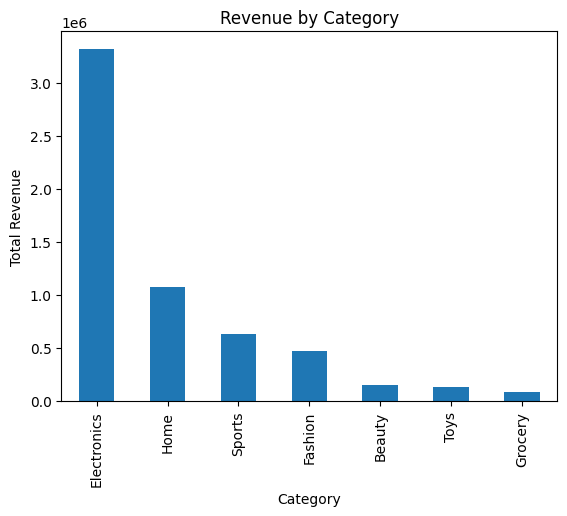

In [63]:
category_revenue = df.groupby("category")["total_amount"].sum().sort_values(ascending=False)
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel('Category')
plt.ylabel("Total Revenue")
plt.show()

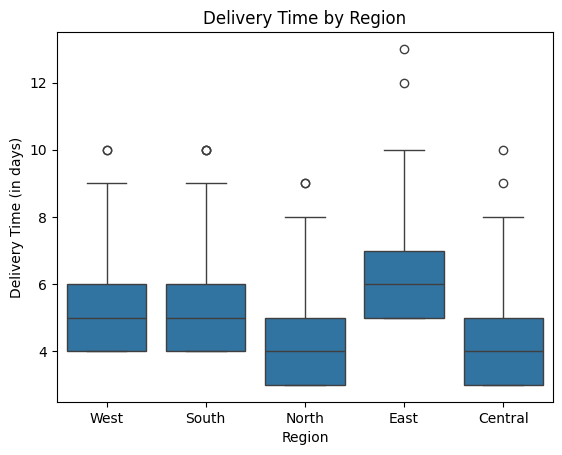

region
Central    4.006392
East       5.988847
North      3.984680
South      5.005406
West       5.000881
Name: delivery_time_days, dtype: float64

In [64]:
sns.boxplot(data=df, x="region", y="delivery_time_days")
plt.title("Delivery Time by Region")
plt.xlabel('Region')
plt.ylabel('Delivery Time (in days)')
plt.show()

df.groupby("region")["delivery_time_days"].mean()

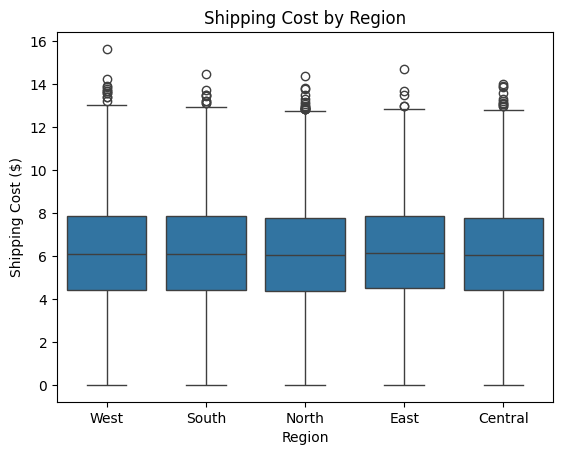

region
Central    6.120098
East       6.199684
North      6.109379
South      6.162234
West       6.166645
Name: shipping_cost, dtype: float64

In [65]:
sns.boxplot(data=df, x="region", y="shipping_cost")
plt.title("Shipping Cost by Region")
plt.xlabel('Region')
plt.ylabel('Shipping Cost ($)')
plt.show()

df.groupby("region")["shipping_cost"].mean()

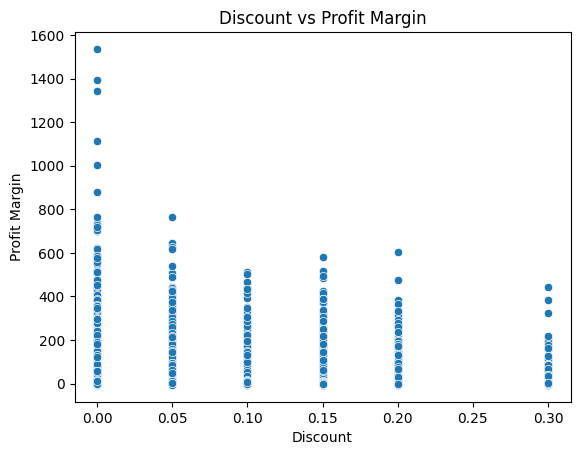

In [66]:
sns.scatterplot(data=df, x="discount", y="profit_margin")
plt.title("Discount vs Profit Margin")
plt.xlabel('Discount')
plt.ylabel('Profit Margin')
plt.show()

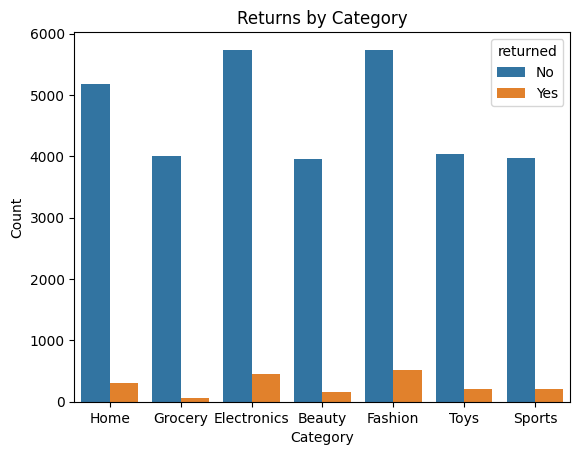

In [67]:
return_rate = (df.groupby("category")["returned"].value_counts(normalize=True).unstack())

return_rate["Yes"].sort_values(ascending=False)
sns.countplot(data=df, x="category", hue="returned")
plt.title("Returns by Category")
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

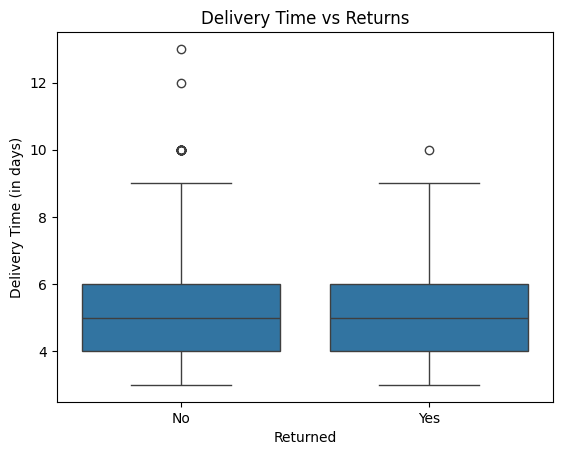

In [68]:
sns.boxplot(data=df, x="returned", y="delivery_time_days")
plt.title("Delivery Time vs Returns")
plt.xlabel('Returned')
plt.ylabel('Delivery Time (in days)')
plt.show()

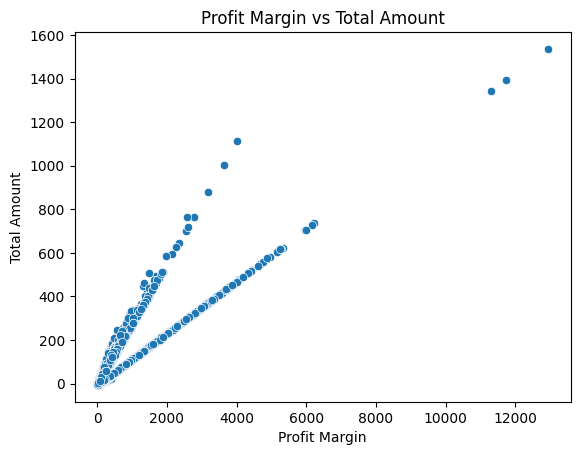

In [69]:
sns.scatterplot(data=df, x="total_amount", y="profit_margin")
plt.xlabel('Profit Margin')
plt.ylabel('Total Amount')
plt.title("Profit Margin vs Total Amount")
plt.show()


In [70]:
df.groupby('month')['profit_margin'].mean()

month
1     26.011998
2     27.468694
3     27.835926
4     29.922626
5     29.236176
6     28.174226
7     29.031073
8     26.804548
9     27.078308
10    28.731112
11    28.502665
12    28.452426
Name: profit_margin, dtype: float64

## 3.2 Correlation Analysis
Analyze correlations between numerical features

In [71]:
df[["customer_age", "total_amount"]].corr() #very low correlation between customer age and total amount

,customer_age,total_amount
customer_age,1.00000,-0.00987
total_amount,-0.00987,1.00000


In [72]:
df[["discount", "total_amount"]].corr()

,discount,total_amount
discount,1.000000,-0.031202
total_amount,-0.031202,1.000000


In [73]:
df[["discount", "profit_margin"]].corr()

,discount,profit_margin
discount,1.00000,-0.04747
profit_margin,-0.04747,1.00000


In [74]:
df[["total_amount", "profit_margin"]].corr()

,total_amount,profit_margin
total_amount,1.000000,0.893327
profit_margin,0.893327,1.000000


In [75]:
df[["price", "profit_margin"]].corr()

,price,profit_margin
price,1.000000,0.679105
profit_margin,0.679105,1.000000


In [76]:
df[["shipping_cost", "profit_margin"]].corr()

,shipping_cost,profit_margin
shipping_cost,1.00000,0.61673
profit_margin,0.61673,1.00000


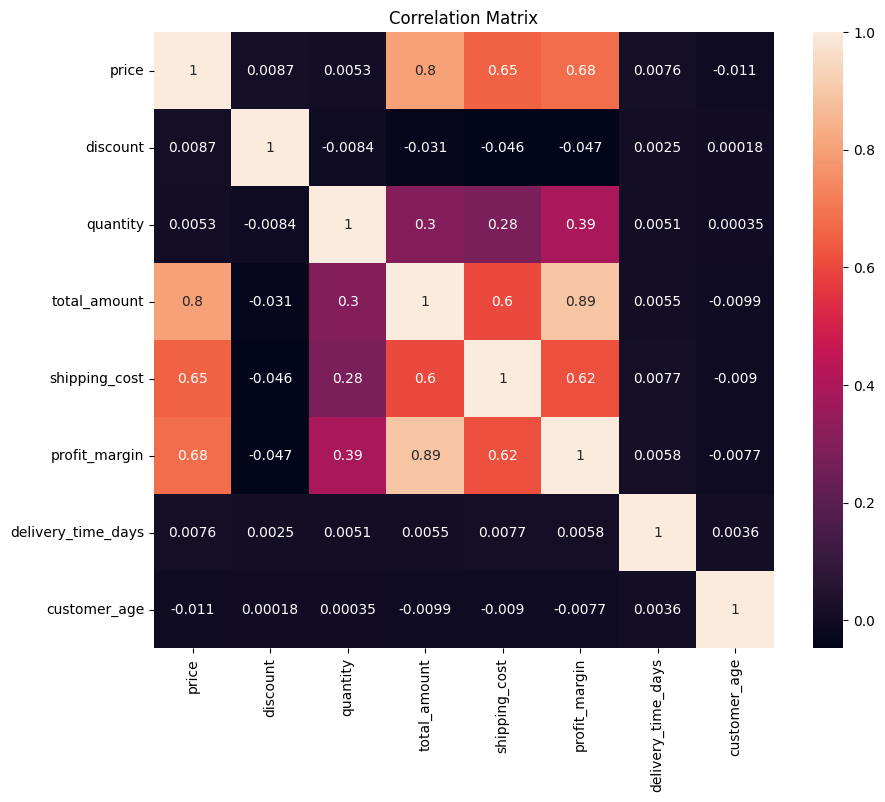

In [77]:
numeric_cols = [
    "price",
    "discount",
    "quantity",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "delivery_time_days",
    "customer_age"
]

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">4. Scaling, Categorical Variables, and Splitting</p>

<a id="4"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>


In [78]:
import sys
!{sys.executable} -m pip install scikit-learn
#Dropping irrelevant columns from model
df = df.drop(['customer_id', 'order_id', 'product_id', 'order_date'], axis = 1)

#Splitting data into train and test sets (80% train and 20% test)
X = df.drop('profit_margin', axis = 1)
y = df['profit_margin']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8)

#One-Hot Encoding to handle categorical variables
from sklearn.preprocessing import OneHotEncoder
X_train = pd.get_dummies(X_train, columns = ['category', 'payment_method', 'region', 'returned', 'customer_gender'])
X_test = pd.get_dummies(X_test, columns= ['category', 'payment_method', 'region', 'returned', 'customer_gender'])

#Scaling numerical columns to improve model performance
from sklearn.preprocessing import StandardScaler
numerical_columns = ['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'customer_age']
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


In [105]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("scaler.pkl")

scaler.pkl


In [104]:
X_train.columns

Index(['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount',
       'shipping_cost', 'customer_age', 'year', 'month', 'day', 'quarter',
       'category_Beauty', 'category_Electronics', 'category_Fashion',
       'category_Grocery', 'category_Home', 'category_Sports', 'category_Toys',
       'payment_method_COD', 'payment_method_Credit Card',
       'payment_method_Debit Card', 'payment_method_PayPal',
       'payment_method_UPI', 'payment_method_Wallet', 'region_Central',
       'region_East', 'region_North', 'region_South', 'region_West',
       'returned_No', 'returned_Yes', 'customer_gender_Female',
       'customer_gender_Male', 'customer_gender_Other'],
      dtype='object')

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">5. Models</p>

<a id="5"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 5.1 Creating Models
Building and evaluating baseline models using different machine learning algorithms.

In [79]:
# Evaluation function for baseline models
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
def train_val(model, name, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    scores = {
        name+" Train": {
            "R2": r2_score(y_train, y_train_pred),
            "MAE": mean_absolute_error(y_train, y_train_pred),
            "MSE": mean_squared_error(y_train, y_train_pred),
            "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred))
        },
        name+" Test": {
            "R2": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
        }
    }

    return pd.DataFrame(scores)

### 5.1.1 Linear Regression

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

LR = LinearRegression()

# Cross Validation
cv_scores_lr = cross_val_score(LR, X_train, y_train, cv=5)
print("Linear Regression Cross Validation R2 scores:", cv_scores_lr)
print("Linear Regression Average Cross Validation R2:", np.mean(cv_scores_lr))

# Fit
LR.fit(X_train, y_train)

# Predictions
y_pred_lr = LR.predict(X_test)
y_train_pred_lr = LR.predict(X_train)

# Evaluation
results_lr = train_val(LR, "Linear Regression Model", X_train, y_train, X_test, y_test)
results_lr

Linear Regression Cross Validation R2 scores: [0.87572582 0.87713933 0.88301663 0.88117141 0.88640231]
Linear Regression Average Cross Validation R2: 0.8806911004048141


,Linear Regression Model Train,Linear Regression Model Test
R2,0.881380,0.885036
MAE,10.379254,10.571654
MSE,329.284552,359.604571
RMSE,18.146199,18.963243


### 5.1.2 Support Vector Regression

In [81]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize model
svr_model = SVR()

# Cross Validation (on training data only)
cv_scores_svr = cross_val_score(svr_model, X_train, y_train, cv=5)

print("Support Vector Regression Cross Validation R2 scores:", cv_scores_svr)
print("Support Vector Regression Average Cross Validation R2:", np.mean(cv_scores_svr))

# Fit model
svr_model.fit(X_train, y_train)

# Predictions
y_train_pred_svr = svr_model.predict(X_train)
y_test_pred_svr = svr_model.predict(X_test)

# Evaluation
results_svr = train_val(svr_model, "Support Vector Regression", X_train, y_train, X_test, y_test)

results_svr

Support Vector Regression Cross Validation R2 scores: [-0.11136862 -0.11075553 -0.11280599 -0.10200983 -0.10408981]
Support Vector Regression Average Cross Validation R2: -0.10820595353192272


,Support Vector Regression Train,Support Vector Regression Test
R2,-0.107628,-0.104250
MAE,25.789990,26.687519
MSE,3074.720805,3454.078719
RMSE,55.450165,58.771411


### 5.1.3 Random Forest Regression

In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize model
rf_model = RandomForestRegressor(n_estimators=100)

# Cross Validation
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print("Random Forest Cross Validation R2 scores:", cv_scores_rf)
print("Random Forest Average Cross Validation R2:", np.mean(cv_scores_rf))

# Fit model
rf_model.fit(X_train, y_train)

# Evaluate
results_rf = train_val(rf_model, "Random Forest", X_train, y_train, X_test, y_test)

results_rf

Random Forest Cross Validation R2 scores: [0.99215123 0.99373419 0.99504283 0.9837062  0.9879016 ]
Random Forest Average Cross Validation R2: 0.9905072095556907


,Random Forest Train,Random Forest Test
R2,0.998675,0.991945
MAE,0.140863,0.369289
MSE,3.679462,25.197479
RMSE,1.918192,5.019709


### 5.1.4 XG Boost

In [83]:
import sys
!{sys.executable} -m pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize model
xgb_model = XGBRegressor()

# Cross Validation
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')

print("XGBoost Cross Validation R2 scores:", cv_scores_xgb)
print("XGBoost Average Cross Validation R2:", np.mean(cv_scores_xgb))

# Fit model
xgb_model.fit(X_train, y_train)

# Evaluate
results_xgb = train_val(xgb_model, "XGBoost", X_train, y_train, X_test, y_test)

results_xgb

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
XGBoost Cross Validation R2 scores: [0.98589981 0.9870227  0.96015643 0.94470403 0.95614751]
XGBoost Average Cross Validation R2: 0.9667860953672751


,XGBoost Train,XGBoost Test
R2,0.999870,0.967890
MAE,0.342183,0.905830
MSE,0.360405,100.440834
RMSE,0.600338,10.022017


### 5.1.5 LightGBM

In [84]:
import sys
!{sys.executable} -m pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize default model
lgb_model = LGBMRegressor()

# Cross-validation
cv_scores_lgb = cross_val_score(lgb_model, X_train, y_train, cv=5, scoring='r2')

print("LightGBM Cross Validation R2 scores:", cv_scores_lgb)
print("LightGBM Average Cross Validation R2:", np.mean(cv_scores_lgb))

# Fit model
lgb_model.fit(X_train, y_train)

# Evaluate
results_lgb = train_val(lgb_model, "LightGBM", X_train, y_train, X_test, y_test)

results_lgb

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 22080, number of used features: 34
[LightGBM] [Info] Start training from score 28.004101
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 916
[LightGBM] [Info] Number of data points in the train set: 22080, number

,LightGBM Train,LightGBM Test
R2,0.988267,0.954802
MAE,0.806772,1.272234
MSE,32.571096,141.377930
RMSE,5.707109,11.890245


### 5.1.6 CatBoost

In [85]:
import sys
!{sys.executable} -m pip install catboost
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize CatBoost model
catboost_model = CatBoostRegressor()

# Cross-validation 
cv_scores_catboost = cross_val_score(catboost_model, X_train, y_train, cv=5, scoring='r2')

print("CatBoost Cross Validation R2 scores:", cv_scores_catboost)
print("CatBoost Average Cross Validation R2:", np.mean(cv_scores_catboost))

# Fit model
catboost_model.fit(X_train, y_train)

# Evaluate
results_catboost = train_val(catboost_model, "CatBoost", X_train, y_train, X_test, y_test)

results_catboost

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
Learning rate set to 0.066762
0:	learn: 50.0119688	total: 59.6ms	remaining: 59.6s
1:	learn: 47.2403509	total: 61.4ms	remaining: 30.6s
2:	learn: 44.6951873	total: 62.9ms	remaining: 20.9s
3:	learn: 42.3679923	total: 64.6ms	remaining: 16.1s
4:	learn: 40.1768184	total: 66ms	remaining: 13.1s
5:	learn: 38.1169882	total: 67.5ms	remaining: 11.2s
6:	learn: 36.1705393	total: 68.7ms	remaining: 9.75s
7:	learn: 34.3331675	total: 70.2ms	remaining: 8.7s
8:	learn: 32.6171084	total: 71.8ms	remaining: 7.9s
9:	learn: 30.9852737	total: 73.2ms	remaining: 7.25s
10:	learn: 29.5349218	total: 74.5ms	remaining: 6.7s
11:	learn: 28.1730343	total: 76ms	remaining: 6.26s
12:	learn: 26.8957697	total: 77.6ms	remaining: 5.89s
13:	learn: 25.7386391	total: 79ms	remaining: 5.56s
14:	learn: 24.6186033	total: 80.3ms	remaining: 5.27s
15:	learn: 23.6115645	total: 81.6ms	remaining: 5.02s
16:	learn: 22.6703077	total: 83.2ms	r

,CatBoost Train,CatBoost Test
R2,0.999664,0.974542
MAE,0.500225,0.929494
MSE,0.932044,79.632703
RMSE,0.965424,8.923716


## 5.2 Default Model Comparisons
Comparing the performance of different baseline models.

In [86]:
import pandas as pd

models_results = pd.concat([results_lr, results_svr, results_rf, results_xgb, results_lgb, results_catboost], axis=1)

models_results

,Linear Regression Model Train,Linear Regression Model Test,Support Vector Regression Train,Support Vector Regression Test,Random Forest Train,Random Forest Test,XGBoost Train,XGBoost Test,LightGBM Train,LightGBM Test,CatBoost Train,CatBoost Test
R2,0.881380,0.885036,-0.107628,-0.104250,0.998675,0.991945,0.999870,0.967890,0.988267,0.954802,0.999664,0.974542
MAE,10.379254,10.571654,25.789990,26.687519,0.140863,0.369289,0.342183,0.905830,0.806772,1.272234,0.500225,0.929494
MSE,329.284552,359.604571,3074.720805,3454.078719,3.679462,25.197479,0.360405,100.440834,32.571096,141.377930,0.932044,79.632703
RMSE,18.146199,18.963243,55.450165,58.771411,1.918192,5.019709,0.600338,10.022017,5.707109,11.890245,0.965424,8.923716


## 5.3 Feature Importance
Analyzing and explaining the most important features in CatBoost model as it has the highest train and test R2 scores:

In [87]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
4,total_amount,62.338638
12,category_Electronics,26.289072
0,price,4.140063
2,quantity,3.084008
5,shipping_cost,0.775599
1,discount,0.637153
14,category_Grocery,0.535958
11,category_Beauty,0.451739
13,category_Fashion,0.401246
6,customer_age,0.323576


Correlation results show that there is high correlation between total amount and profit margin (0.89), between price and profit margin (0.67), and between shipping cost and profit margin (0.61). The CatBoost's feature importance shows that total amount, price, and quantity are strongly influencing predictions of profit margin. Because total amount and price might be mathematically related to the profit margin, it is entirely possible that the model is utilizing these relationships rather than learning patterns. To create a more realistic model, the next steps include dropping the total amount and price columns from the feature set, retraining the baseline models, recomputing the feature importances, and then tuning the hyperparameters before selecting the final model.

## 5.4 Fine-Tuning Models 

In [88]:
#Dropping the leakage features from the feature set (both train and test)
X_train_new = X_train.drop(['total_amount', 'price'], axis = 1)
X_test_new = X_test.drop(['total_amount', 'price'], axis = 1)


### 5.4.1 Linear Regression

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

LR = LinearRegression()

# Cross Validation
cv_scores_lr_new = cross_val_score(LR, X_train_new, y_train, cv=5)
print("New Linear Regression Cross Validation R2 scores:", cv_scores_lr_new)
print("New Linear Regression Average Cross Validation R2:", np.mean(cv_scores_lr_new))

# Fit
LR.fit(X_train_new, y_train)

# Predictions
y_pred_lr_new = LR.predict(X_test_new)
y_train_pred_lr_new = LR.predict(X_train_new)

# Evaluation
results_lr_new = train_val(LR, "New Linear Regression Model", X_train_new, y_train, X_test_new, y_test)
results_lr_new

New Linear Regression Cross Validation R2 scores: [0.43621709 0.43967853 0.46304685 0.42614577 0.42501036]
New Linear Regression Average Cross Validation R2: 0.438019720111906


,New Linear Regression Model Train,New Linear Regression Model Test
R2,0.438667,0.431965
MAE,22.380231,22.836581
MSE,1558.233796,1776.805019
RMSE,39.474470,42.152165


### 5.4.2 Support Vector Regression

In [90]:
#DEFAULT SUPPORT VECTOR REGRESSION MODEL AFTER DROPPING
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize model
svr_model_new = SVR()

# Cross Validation
cv_scores_svr_new = cross_val_score(svr_model_new, X_train_new, y_train, cv=5)

print("New Support Vector Regression Cross Validation R2 scores:", cv_scores_svr_new)
print("New Support Vector Regression Average Cross Validation R2:", np.mean(cv_scores_svr_new))

# Fit model
svr_model_new.fit(X_train_new, y_train)

# Predictions
y_train_pred_svr_new = svr_model_new.predict(X_train_new)
y_test_pred_svr_new = svr_model_new.predict(X_test_new)

# Evaluation
results_svr_new = train_val(svr_model_new, "New Support Vector Regression", X_train_new, y_train, X_test_new, y_test)

results_svr_new

New Support Vector Regression Cross Validation R2 scores: [-0.11170265 -0.11109003 -0.1131299  -0.10232767 -0.10440369]
New Support Vector Regression Average Cross Validation R2: -0.10853078775884195


,New Support Vector Regression Train,New Support Vector Regression Test
R2,-0.108016,-0.104642
MAE,25.795458,26.693223
MSE,3075.798758,3455.304688
RMSE,55.459884,58.781840


In [91]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base model
svr = SVR()

param_dist = {
    "kernel": ["rbf", "poly"],          
    "C": [0.1, 1, 10, 50, 100],        
    "gamma": ["scale", "auto", 0.01, 0.1],
    "epsilon": [0.01, 0.1, 0.5],
    "degree": [2, 3]
}

random_search_svr = RandomizedSearchCV(estimator=svr, param_distributions=param_dist, n_iter=20, cv=3, scoring="r2", n_jobs=2,random_state=30)

# Fit
random_search_svr.fit(X_train_new, y_train)

# Best model
best_svr = random_search_svr.best_estimator_

print("Best Parameters:", random_search_svr.best_params_)
print("Best CV R2:", random_search_svr.best_score_)

# Predictions
y_train_pred = best_svr.predict(X_train_new)
y_test_pred = best_svr.predict(X_test_new)

# Train metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

# Test metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("\nTrain Metrics")
print("R2:", train_r2)
print("MAE:", train_mae)
print("MSE:", train_mse)
print("RMSE:", train_rmse)

print("\nTest Metrics")
print("R2:", test_r2)
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)

KeyboardInterrupt: 

### 5.4.3 Random Forest Regression

In [92]:
#Baseline model after dropping the highly correlated features

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize model
rf_model = RandomForestRegressor(n_estimators=100, random_state = 30)

# Cross Validation
cv_scores_rf_new = cross_val_score(rf_model, X_train_new, y_train, cv=5, scoring='r2')
print("New Random Forest Cross Validation R2 scores:", cv_scores_rf_new)
print("New Random Forest Average Cross Validation R2:", np.mean(cv_scores_rf_new))

# Fit model
rf_model.fit(X_train_new, y_train)

# Evaluate
results_rf = train_val(rf_model, "Random Forest", X_train_new, y_train, X_test_new, y_test)

results_rf

New Random Forest Cross Validation R2 scores: [0.59481806 0.65903576 0.64384868 0.63339632 0.6365528 ]
New Random Forest Average Cross Validation R2: 0.6335303207426476


,Random Forest Train,Random Forest Test
R2,0.949242,0.661662
MAE,5.447235,15.079453
MSE,140.900399,1058.317332
RMSE,11.870147,32.531790


In [93]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Base model
rf_model = RandomForestRegressor(random_state=30, n_jobs=-1)

param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 0.6, 0.8], 
    'bootstrap': [True, False]
}

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=30)

# Randomized Search
random_search_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist, n_iter=30, scoring='r2', cv=cv, random_state=30, n_jobs=-1)

# Fit
random_search_rf.fit(X_train_new, y_train)

# Best model
best_rf = random_search_rf.best_estimator_

print("Best Parameters:", random_search_rf.best_params_)
print("Best CV R²:", random_search_rf.best_score_)


# Evaluate
results_rf = train_val(best_rf, "Random Forest", X_train_new, y_train, X_test_new, y_test)

results_rf

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.6, 'max_depth': 20, 'bootstrap': True}
Best CV R²: 0.6656581830056603


,Random Forest Train,Random Forest Test
R2,0.751344,0.681790
MAE,11.942973,14.239277
MSE,690.256566,995.355962
RMSE,26.272734,31.549262


In [94]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf_model = RandomForestRegressor(random_state=30, n_jobs=-1)

param_dist_refined = {
    'n_estimators': [400, 500, 600],
    'max_depth': [8, 10, 12],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [8, 10, 12],
    'max_features': [0.7, 0.8, 0.85],
    'bootstrap': [True]  
}

cv = KFold(n_splits=5, shuffle=True, random_state=30)

random_search_rf_refined = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist_refined, n_iter=20, scoring='r2', cv=cv, random_state=30, n_jobs=-1)

random_search_rf_refined.fit(X_train_new, y_train)

print("Best Refined Parameters:", random_search_rf_refined.best_params_)
print("Best Refined CV R²:", random_search_rf_refined.best_score_)

best_rf_refined = random_search_rf_refined.best_estimator_
y_pred_refined = best_rf_refined.predict(X_test_new)

results_rf_refined = train_val(best_rf_refined, "Random Forest Refined", X_train_new, y_train, X_test_new, y_test)

results_rf_refined

Best Refined Parameters: {'n_estimators': 600, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 0.7, 'max_depth': 8, 'bootstrap': True}
Best Refined CV R²: 0.6658186171621227


,Random Forest Refined Train,Random Forest Refined Test
R2,0.726939,0.687947
MAE,13.207591,14.148017
MSE,758.004329,976.097003
RMSE,27.531878,31.242551


### 5.4.4 XG Boost

In [95]:
#Default XG Boost after dropping leakage variables 
import sys
!{sys.executable} -m pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize model
xgb_model_new = XGBRegressor()

# Cross Validation
cv_scores_xgb_new = cross_val_score(xgb_model_new, X_train_new, y_train, cv=5, scoring='r2')

print("New XGBoost Cross Validation R2 scores:", cv_scores_xgb_new)
print("New XGBoost Average Cross Validation R2:", np.mean(cv_scores_xgb_new))

# Fit model
xgb_model_new.fit(X_train_new, y_train)

# Evaluate
results_xgb_new = train_val(xgb_model_new, "XGBoost", X_train_new, y_train, X_test_new, y_test)

results_xgb_new

You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.
New XGBoost Cross Validation R2 scores: [0.59422166 0.60145518 0.60175006 0.5693584  0.62252961]
New XGBoost Average Cross Validation R2: 0.597862982669573


,XGBoost Train,XGBoost Test
R2,0.906420,0.643015
MAE,9.679164,15.154271
MSE,259.774096,1116.644664
RMSE,16.117509,33.416234


In [96]:
from sklearn.model_selection import RandomizedSearchCV, KFold

param_dist = {
    'n_estimators': [300, 400, 500, 600],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 5, 6, 7],
    'min_child_weight': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2]
}

xgb_model_hyperparameters = XGBRegressor(random_state=30, n_jobs=-1)

cv = KFold(n_splits=5, shuffle=True, random_state=30)

random_search_xgb = RandomizedSearchCV(estimator=xgb_model_hyperparameters, param_distributions=param_dist, n_iter=25, scoring='r2', cv=cv, random_state=30, n_jobs=-1)

random_search_xgb.fit(X_train_new, y_train)

print("Best Parameters:", random_search_xgb.best_params_)
print("Best CV R²:", random_search_xgb.best_score_)

best_xgb = random_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test_new)

Best Parameters: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV R²: 0.6630411229592912


In [97]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predictions on test set
y_pred = best_xgb.predict(X_test_new)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Test R²:", r2)
print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test R²: 0.6810073285025626
Test RMSE: 31.588047119207506
Test MAE: 14.290666094884298


### 5.4.5 Light GBM

In [98]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lgb_model_new = lgb.LGBMRegressor(random_state=30, n_jobs=-1)

lgb_model_new.fit(X_train_new, y_train)

# Evaluate on training set
y_train_pred = lgb_model_new.predict(X_train_new)
train_r2 = r2_score(y_train, y_train_pred)
print("New LightGBM Train R²:", train_r2)

# Evaluate on test set
y_pred = lgb_model_new.predict(X_test_new)
print("New LightGBM Test R²:", r2_score(y_test, y_pred))
print("New LightGBM Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("New LightGBM Test MAE:", mean_absolute_error(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 27600, number of used features: 32
[LightGBM] [Info] Start training from score 27.961191
New LightGBM Train R²: 0.7923360034743085
New LightGBM Test R²: 0.6787003343041798
New LightGBM Test RMSE: 31.70206566073102
New LightGBM Test MAE: 14.397176265353297


In [99]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base LightGBM Model
lgb_model = lgb.LGBMRegressor(random_state=30, n_jobs=-1)

param_dist = {
    'num_leaves': [20, 30, 40, 50, 60],           
    'max_depth': [5, 8, 10, 12, 15],           
    'learning_rate': [0.01, 0.03, 0.05, 0.1],  
    'n_estimators': [300, 500, 800, 1000],      
    'min_child_samples': [5, 10, 20, 30],      
    'subsample': [0.7, 0.8, 0.9, 1.0],         
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],   
    'reg_alpha': [0, 0.1, 0.5, 1],            
    'reg_lambda': [0, 0.1, 0.5, 1]               
}

# Cross-Validation Setup
cv = KFold(n_splits=5, shuffle=True, random_state=30)

# Randomized Search
random_search_lgb = RandomizedSearchCV(estimator=lgb_model, param_distributions=param_dist, n_iter=30, scoring='r2', cv=cv, random_state=30, n_jobs=-1)

# Fit Randomized Search
random_search_lgb.fit(X_train_new, y_train)

print("Best Parameters:", random_search_lgb.best_params_)
print("Best CV R²:", random_search_lgb.best_score_)

# Evaluate on Test Set
best_lgb = random_search_lgb.best_estimator_
y_pred = best_lgb.predict(X_test_new)

print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

# Evaluate on Train Set
y_train_pred = best_lgb.predict(X_train_new)
train_r2 = r2_score(y_train, y_train_pred)
print("Train R²:", train_r2)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 22080, number of used features: 32
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010479 seconds.
You can set `force_col_wise=true` to remove t

In [100]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base LightGBM Model
lgb_model = lgb.LGBMRegressor(random_state=30, n_jobs=-1)

# Refined Hyperparameter Space
param_dist = {
    'num_leaves': [31, 50, 70],               
    'max_depth': [5, 8, 10],                 
    'learning_rate': [0.01, 0.03, 0.05],     
    'n_estimators': [200, 300, 400],        
    'min_child_samples': [10, 20, 30],       
    'subsample': [0.7, 0.8, 0.9],            
    'colsample_bytree': [0.6, 0.7, 0.8],     
    'reg_alpha': [0, 0.1, 0.5],              
    'reg_lambda': [0, 0.1, 0.5]              
}

# 5-Fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=30)

random_search_lgb = RandomizedSearchCV(estimator=lgb_model, param_distributions=param_dist, n_iter=20, scoring='r2', cv=cv, random_state=30, n_jobs=-1)

# Fit Randomized Search
random_search_lgb.fit(X_train_new, y_train, eval_set=[(X_train_new, y_train)], eval_metric='rmse')

print("Best Parameters:", random_search_lgb.best_params_)
print("Best CV R²:", random_search_lgb.best_score_)

# Evaluate on Test Set
best_lgb = random_search_lgb.best_estimator_
y_pred = best_lgb.predict(X_test_new)

print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 22080, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 27.828374
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 22080, number of used

### 5.4.6 CatBoost

In [101]:
#Default CatBoost model after dropping the leakage variables from the feature set

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import numpy as np

# Initialize CatBoost model
catboost_model_new = CatBoostRegressor(random_state = 30)

#Cross Validation
cv = KFold(n_splits = 5, shuffle = True)
cv_scores_catboost_new = cross_val_score(catboost_model_new, X_train_new, y_train, cv=cv, scoring='r2')

print("New CatBoost Model Cross Validation R2 scores:", cv_scores_catboost_new)
print("New CatBoost Model Average Cross Validation R2:", np.mean(cv_scores_catboost_new))

# Fit model
catboost_model_new.fit(X_train_new, y_train)

# Evaluate
results_catboost_new = train_val(catboost_model_new, "CatBoost", X_train_new, y_train, X_test_new, y_test)

results_catboost_new

Learning rate set to 0.066762
0:	learn: 51.8843053	total: 3.09ms	remaining: 3.08s
1:	learn: 50.0435652	total: 4.86ms	remaining: 2.42s
2:	learn: 48.3855665	total: 7ms	remaining: 2.33s
3:	learn: 46.8092145	total: 8.75ms	remaining: 2.18s
4:	learn: 45.4109837	total: 10ms	remaining: 2s
5:	learn: 44.0511687	total: 11.6ms	remaining: 1.93s
6:	learn: 42.8210942	total: 13.1ms	remaining: 1.86s
7:	learn: 41.7229177	total: 14.8ms	remaining: 1.83s
8:	learn: 40.8002503	total: 16.1ms	remaining: 1.77s
9:	learn: 39.9076570	total: 17.6ms	remaining: 1.74s
10:	learn: 39.1123066	total: 18.9ms	remaining: 1.7s
11:	learn: 38.3948508	total: 20.3ms	remaining: 1.67s
12:	learn: 37.6843435	total: 21.6ms	remaining: 1.64s
13:	learn: 37.0713460	total: 23ms	remaining: 1.62s
14:	learn: 36.4875331	total: 24.3ms	remaining: 1.6s
15:	learn: 35.9840161	total: 25.7ms	remaining: 1.58s
16:	learn: 35.4762839	total: 27.1ms	remaining: 1.57s
17:	learn: 35.0085169	total: 28.6ms	remaining: 1.56s
18:	learn: 34.5996869	total: 29.9ms	re

,CatBoost Train,CatBoost Test
R2,0.855339,0.674716
MAE,11.425651,14.403429
MSE,401.570567,1017.485204
RMSE,20.039226,31.898044


In [102]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Base model
cat_model = CatBoostRegressor(random_state=30)

param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'iterations': [300, 500, 800, 1000],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'bagging_temperature': [0, 0.2, 0.5, 0.8, 1]
}

# Randomized search
random_search = RandomizedSearchCV(estimator=cat_model, param_distributions=param_dist, n_iter=20, scoring='r2', cv=5, random_state=30, n_jobs=-1)

# Fit search
random_search.fit(X_train_new, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

# Best model
best_model = random_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train_new)
y_test_pred = best_model.predict(X_test_new)

# Train metrics
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

# Test metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("\nTrain Metrics")
print("R2:", train_r2)
print("MAE:", train_mae)
print("MSE:", train_mse)
print("RMSE:", train_rmse)

print("\nTest Metrics")
print("R2:", test_r2)
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)

0:	learn: 50.1060507	total: 69.4ms	remaining: 1m 9s
1:	learn: 47.4512106	total: 73.4ms	remaining: 36.6s
0:	learn: 50.2684937	total: 65.7ms	remaining: 1m 5s
2:	learn: 45.1586233	total: 79.7ms	remaining: 26.5s
1:	learn: 47.7083276	total: 71.7ms	remaining: 35.8s
0:	learn: 50.2401489	total: 66.2ms	remaining: 1m 6s
3:	learn: 43.1206631	total: 84.5ms	remaining: 21s
4:	learn: 41.4550218	total: 87.3ms	remaining: 17.4s
2:	learn: 45.4179241	total: 78.4ms	remaining: 26.1s
5:	learn: 39.8626569	total: 90ms	remaining: 14.9s
3:	learn: 43.2920446	total: 82.2ms	remaining: 20.5s
6:	learn: 38.5076997	total: 93.2ms	remaining: 13.2s
4:	learn: 41.6607068	total: 84.8ms	remaining: 16.9s
7:	learn: 37.3264786	total: 96.3ms	remaining: 11.9s
1:	learn: 47.6624505	total: 78.3ms	remaining: 39.1s
5:	learn: 40.1923715	total: 88ms	remaining: 14.6s
0:	learn: 49.6630760	total: 67.1ms	remaining: 1m 7s
8:	learn: 36.2539459	total: 99.6ms	remaining: 11s
2:	learn: 45.4060959	total: 81.8ms	remaining: 27.2s
6:	learn: 38.8192781

## 5.5 Final Model
Choosing the best-performing model based on evaluations and fine-tuning.

The best-performing model is Support Vector Regression because it has the highest test R² score with barely any overfitting. The small difference between the training and test performance shows that the model is generalizing well to new data.

## 5.6 Pickle the Model
Saving the final model for future deployment:

In [103]:
import pickle

with open("best_svr_model.pkl", "wb") as f:
    pickle.dump(best_svr, f)

print("Best_svr_model.pkl")

NameError: name 'best_svr' is not defined

In [106]:
import pickle

with open("best_rf_model.pkl", "wb") as f:
    pickle.dump(random_search_rf_refined, f)

print("best_rf_model.pkl")

best_rf_model.pkl


## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">6. Conclusion</p>

<a id="6"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## Final Remarks
Summarizing the key takeaways from the project.

**Analysis Insights**
1) Revenue is Mostly Influenced by Price and Quantity

The strongest correlations were:

* Total Amount & Profit Margin → 0.89
* Total Amount & Price → 0.80
* Total Amount & Shipping Cost → 0.60
* Total Amount & Quantity → 0.30

Total amount is largely influenced by product price and quantity purchased. Since profit margin is strongly correlated with total amount (0.89), this shows that higher revenue purchases tend to lead to higher profit.

Company’s profit is influenced by:

* Product pricing
* Purchasing quantity

Instead of other factors like customer demographics or delivery time.

2) Discounts do not appear to influence revenue or profit

Discounts have extremely less correlation with:

* Total amount
* Profit margin
* Quantity

This suggests that discounts do not tend to lead to higher spending or profits. 

3) Customer age does not strongly impact spending

Customer age shows almost no correlation with:

* Total amount
* Profit margin
* Quantity

Spending behavior is consistent across different ages.

4) Delivery time does not influence spending

Delivery time days also shows less correlation with revenue and profit.
Customers are not spending more or less based on delivery speed.

**Additional Business Insights**
1) The majority of the purchases are from the Electronics category.

Most purchases occur in the Electronics category, making it the most frequently bought product type.
Marketing efforts in Electronics could generate strong returns.

2) Customers in their mid-20s to 30s spend the most
The highest total spending appears to come from customers in their mid-20s and 30s.

3) Both genders primarily purchase Electronics and Fashion
Both male and female customers show strong purchasing activity in the Electronics and Fashion categories.

4) The south region has the highest purchase count
Most purchases come from the South region, while the Central region has the lowest purchase activity.

This insight could help with:
Regional marketing
Distribution centers
Promotional campaigns

......